## 프로젝트 : mini BERT 만들기

### 0. 환경 구성

In [1]:
import os
import re
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchsummary import summary
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import sentencepiece as spm


In [2]:
random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.7.1+cu118
device: cuda


### 1. Tokenizer: ko_8000

```bash

$ python
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = os.getenv('HOME')+'/work/bert_pretrain/data/kowiki.txt'
>>> prefix = os.getenv('HOME')+'/work/bert_pretrain/models/ko_8000'
>>> vocab_size = 8000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")

```


In [3]:
model_dir = os.getenv("HOME") + "/work/bert_pretrain/models"
os.makedirs(model_dir, exist_ok=True)
spm_model_prefix = f"{model_dir}/ko_8000"
spm_model_path = f"{spm_model_prefix}.model"

corpus_path = os.getenv("HOME") + "/work/bert_pretrain/data/kowiki.txt"

if not os.path.exists(spm_model_path):
    spm_cmd = (
        f"--input={corpus_path} "
        f"--model_prefix={spm_model_prefix} "
        f"--vocab_size=8000 "
        "--model_type=bpe "
        "--character_coverage=0.9995 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[CLS],[SEP],[MASK]"
    )
    SentencePieceTrainer.Train(spm_cmd)

vocab = spm.SentencePieceProcessor()
assert vocab.load(spm_model_path), "ko_8000.model 로드 실패"
vocab_size = vocab.get_piece_size()

PAD_ID = vocab.PieceToId("[PAD]")
UNK_ID = vocab.PieceToId("[UNK]")
BOS_ID = vocab.PieceToId("[BOS]")
EOS_ID = vocab.PieceToId("[EOS]")
SEP_ID = vocab.PieceToId("[SEP]")
CLS_ID = vocab.PieceToId("[CLS]")
MASK_ID = vocab.PieceToId("[MASK]")

print("vocab_size:", vocab_size)
print("PAD:", PAD_ID, "CLS:", CLS_ID, "SEP:", SEP_ID, "MASK:", MASK_ID)

vocab_size: 8007
PAD: 0 CLS: 5 SEP: 4 MASK: 6


### 2. 한글 위키 코퍼스 로드 및 문단/문장 분리

In [4]:
corpus_path = os.getenv("HOME") + "/work/bert_pretrain/data/kowiki.txt"

def iter_paragraphs(path, max_paragraphs=None):
    buf = []
    count = 0
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if buf:
                    yield " ".join(buf)
                    buf = []
                    count += 1
                    if max_paragraphs and count >= max_paragraphs:
                        break
            else:
                buf.append(line)
    if buf:
        yield " ".join(buf)

# 충분한 한글 코퍼스 사용 (시간 고려해서 5만 문단)
max_paragraphs = 50000
paragraphs = list(iter_paragraphs(corpus_path, max_paragraphs=max_paragraphs))
print("num paragraphs:", len(paragraphs))


num paragraphs: 50000


In [5]:
# 간단한 문장 분리기 (마침표/물음표/느낌표 기준)
def split_sentences(text):
    sents = re.split(r"([.!?])", text)
    merged = []
    for i in range(0, len(sents)-1, 2):
        merged.append((sents[i] + sents[i+1]).strip())
    return [s for s in merged if len(s) > 0]

sentences_by_paragraph = [split_sentences(p) for p in paragraphs]
print("예시 문장 수:", sum(len(p) for p in sentences_by_paragraph))

예시 문장 수: 1080995


### 3. NSP용 문장쌍 생성 + SentencePiece 토크나이즈 + MLM 마스크

In [6]:
# NSP 샘플 생성
def create_nsp_samples(sentences_by_p, n_samples=200000):
    all_sentences = [s for p in sentences_by_p for s in p]
    samples = []
    for _ in tqdm(range(n_samples), desc="create NSP samples"):
        p = random.choice(sentences_by_p)
        if len(p) < 2:
            continue
        # A 문장
        idx = random.randint(0, len(p)-2)
        sent_a = p[idx]
        # 실제 다음 문장 또는 랜덤 문장
        if random.random() < 0.5:
            sent_b = p[idx+1]
            label = 1  # is_next
        else:
            sent_b = random.choice(all_sentences)
            label = 0
        samples.append((sent_a, sent_b, label))
    return samples

nsp_raw_samples = create_nsp_samples(sentences_by_paragraph)
print("NSP raw samples:", len(nsp_raw_samples))

# SentencePiece 기반 토크나이즈 및 ID 변환
def encode_sent(text):
    return vocab.EncodeAsIds(text)

def build_input_ids(sent_a, sent_b, max_seq_len=128):
    tokens_a = encode_sent(sent_a)
    tokens_b = encode_sent(sent_b)
    # [CLS] A [SEP] B [SEP]
    tokens = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
    # segment ids: 0 for A, 1 for B
    seg_ids = [0]*(1+len(tokens_a)+1) + [1]*(len(tokens_b)+1)
    # 길이 자르기
    if len(tokens) > max_seq_len:
        tokens = tokens[:max_seq_len]
        seg_ids = seg_ids[:max_seq_len]
    # attention mask & padding
    attn_mask = [1]*len(tokens)
    while len(tokens) < max_seq_len:
        tokens.append(PAD_ID)
        seg_ids.append(0)
        attn_mask.append(0)
    return tokens, seg_ids, attn_mask

# MLM 마스크 생성
def create_mlm_labels(input_ids, mlm_prob=0.15):  # 0.20 -> 0.15
    input_ids = np.array(input_ids)
    labels = np.full_like(input_ids, fill_value=-100)  # ignore_index
    candidate_positions = []
    for i, tid in enumerate(input_ids):
        if tid in (CLS_ID, SEP_ID, PAD_ID):
            continue
        candidate_positions.append(i)
    n_to_mask = max(1, int(len(candidate_positions) * mlm_prob))
    if n_to_mask > 0 and len(candidate_positions) > 0:
        mask_positions = np.random.choice(candidate_positions, n_to_mask, replace=False)
    else:
        mask_positions = []
    for pos in mask_positions:
        original = int(input_ids[pos])
        prob = random.random()
        labels[pos] = original
        if prob < 0.8:
            input_ids[pos] = MASK_ID
        elif prob < 0.9:
            input_ids[pos] = random.randint(0, vocab_size-1)
        else:
            # 그대로 유지
            pass
    return input_ids.tolist(), labels.tolist()

create NSP samples:   0%|          | 0/200000 [00:00<?, ?it/s]

NSP raw samples: 157038


### 4. PyTorch Dataset 구성 (MLM + NSP)

In [7]:
import json

data_dir = os.getenv("HOME") + "/work/bert_pretrain/pretrain_data"
os.makedirs(data_dir, exist_ok=True)

meta_path = os.path.join(data_dir, "bert_pretrain_meta.json")
mm_input_path = os.path.join(data_dir, "input_ids.dat")
mm_seg_path = os.path.join(data_dir, "token_type_ids.dat")
mm_attn_path = os.path.join(data_dir, "attention_mask.dat")
mm_mlm_path = os.path.join(data_dir, "mlm_labels.dat")
mm_nsp_path = os.path.join(data_dir, "nsp_labels.dat")

max_seq_len = 128  # 기존 설정과 동일

num_samples = len(nsp_raw_samples)
print("NSP raw samples:", num_samples)

# memmap 파일 생성 (쓰기 모드)
mm_input = np.memmap(mm_input_path, dtype=np.int32, mode="w+", shape=(num_samples, max_seq_len))
mm_seg   = np.memmap(mm_seg_path,   dtype=np.int32, mode="w+", shape=(num_samples, max_seq_len))
mm_attn  = np.memmap(mm_attn_path,  dtype=np.int32, mode="w+", shape=(num_samples, max_seq_len))
mm_mlm   = np.memmap(mm_mlm_path,   dtype=np.int32, mode="w+", shape=(num_samples, max_seq_len))
mm_nsp   = np.memmap(mm_nsp_path,   dtype=np.int32, mode="w+", shape=(num_samples,))

for idx, (sent_a, sent_b, is_next) in enumerate(tqdm(nsp_raw_samples, desc="build memmap dataset")):
    input_ids, seg_ids, attn_mask = build_input_ids(sent_a, sent_b, max_seq_len)
    mlm_input_ids, mlm_labels = create_mlm_labels(input_ids, mlm_prob=0.15)

    mm_input[idx, :] = np.array(mlm_input_ids, dtype=np.int32)
    mm_seg[idx, :]   = np.array(seg_ids,       dtype=np.int32)
    mm_attn[idx, :]  = np.array(attn_mask,     dtype=np.int32)
    mm_mlm[idx, :]   = np.array(mlm_labels,    dtype=np.int32)
    mm_nsp[idx]      = np.int32(is_next)

# flush to disk
mm_input.flush()
mm_seg.flush()
mm_attn.flush()
mm_mlm.flush()
mm_nsp.flush()

# 메타 정보 json 저장
meta = {
    "num_samples": num_samples,
    "max_seq_len": max_seq_len,
    "vocab_size": vocab_size,
    "paths": {
        "input_ids": mm_input_path,
        "token_type_ids": mm_seg_path,
        "attention_mask": mm_attn_path,
        "mlm_labels": mm_mlm_path,
        "nsp_labels": mm_nsp_path,
    },
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("saved pretrain dataset meta to:", meta_path)


NSP raw samples: 157038


build memmap dataset:   0%|          | 0/157038 [00:00<?, ?it/s]

saved pretrain dataset meta to: /home/jovyan/work/bert_pretrain/pretrain_data/bert_pretrain_meta.json


In [8]:
class BertPretrainDataset(Dataset):
    def __init__(self, meta_json_path):
        with open(meta_json_path, "r", encoding="utf-8") as f:
            meta = json.load(f)

        self.num_samples = meta["num_samples"]
        self.max_seq_len = meta["max_seq_len"]
        paths = meta["paths"]

        # 읽기 전용 memmap
        self.mm_input = np.memmap(paths["input_ids"], dtype=np.int32, mode="r", shape=(self.num_samples, self.max_seq_len))
        self.mm_seg   = np.memmap(paths["token_type_ids"], dtype=np.int32, mode="r", shape=(self.num_samples, self.max_seq_len))
        self.mm_attn  = np.memmap(paths["attention_mask"], dtype=np.int32, mode="r", shape=(self.num_samples, self.max_seq_len))
        self.mm_mlm   = np.memmap(paths["mlm_labels"], dtype=np.int32, mode="r", shape=(self.num_samples, self.max_seq_len))
        self.mm_nsp   = np.memmap(paths["nsp_labels"], dtype=np.int32, mode="r", shape=(self.num_samples,))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        input_ids = torch.from_numpy(self.mm_input[idx].astype(np.int64))
        seg_ids   = torch.from_numpy(self.mm_seg[idx].astype(np.int64))
        attn_mask = torch.from_numpy(self.mm_attn[idx].astype(np.int64))
        mlm_labels= torch.from_numpy(self.mm_mlm[idx].astype(np.int64))
        nsp_label = torch.tensor(self.mm_nsp[idx], dtype=torch.long)
        return input_ids, seg_ids, attn_mask, mlm_labels, nsp_label

# Dataset / DataLoader 생성
dataset = BertPretrainDataset(meta_path)
print("dataset size:", len(dataset))

train_size = int(0.9 * len(dataset))
valid_size = len(dataset) - train_size
train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)


dataset size: 157038


### 5. mini BERT (≈1M params) 정의

In [9]:
class MiniBertConfig:
    def __init__(
        self,
        vocab_size,
        hidden_size=128,
        num_hidden_layers=2,
        num_attention_heads=2,
        intermediate_size=256,
        max_position_embeddings=128,
        type_vocab_size=2,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    ):
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        self.max_position_embeddings = max_position_embeddings
        self.type_vocab_size = type_vocab_size
        self.hidden_dropout_prob = hidden_dropout_prob
        self.attention_probs_dropout_prob = attention_probs_dropout_prob

    def to_dict(self):
        return self.__dict__.copy()

    @classmethod
    def from_dict(cls, d):
        return cls(**d)


def save_config(config, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(config.to_dict(), f, ensure_ascii=False, indent=2)


def load_config(path):
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    return MiniBertConfig.from_dict(d)


class MiniBertEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.word_embeddings = nn.Embedding(config.vocab_size, config.hidden_size)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.token_type_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)
        self.LayerNorm = nn.LayerNorm(config.hidden_size)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, input_ids, token_type_ids):
        seq_len = input_ids.size(1)
        position_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
        word_emb = self.word_embeddings(input_ids)
        pos_emb = self.position_embeddings(position_ids)
        type_emb = self.token_type_embeddings(token_type_ids)
        x = word_emb + pos_emb + type_emb
        x = self.LayerNorm(x)
        x = self.dropout(x)
        return x

class MiniBertSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.hidden_size % config.num_attention_heads == 0
        self.num_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads
        self.all_head_size = self.num_heads * self.head_dim

        self.query = nn.Linear(config.hidden_size, self.all_head_size)
        self.key   = nn.Linear(config.hidden_size, self.all_head_size)
        self.value = nn.Linear(config.hidden_size, self.all_head_size)
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

    def transpose_for_scores(self, x):
        new_shape = x.size()[:-1] + (self.num_heads, self.head_dim)
        x = x.view(*new_shape)
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, attention_mask):
        q = self.transpose_for_scores(self.query(hidden_states))
        k = self.transpose_for_scores(self.key(hidden_states))
        v = self.transpose_for_scores(self.value(hidden_states))

        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.head_dim)
        scores = scores + attention_mask  # mask 적용
        probs = torch.softmax(scores, dim=-1)
        probs = self.dropout(probs)

        context = torch.matmul(probs, v)
        context = context.permute(0, 2, 1, 3).contiguous()
        new_shape = context.size()[:-2] + (self.all_head_size,)
        return context.view(*new_shape)

class MiniBertLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = MiniBertSelfAttention(config)
        self.dense_attn = nn.Linear(config.hidden_size, config.hidden_size)
        self.LayerNorm_attn = nn.LayerNorm(config.hidden_size)
        self.dropout_attn = nn.Dropout(config.hidden_dropout_prob)

        self.intermediate = nn.Linear(config.hidden_size, config.intermediate_size)
        self.intermediate_act = nn.GELU()
        self.output_dense = nn.Linear(config.intermediate_size, config.hidden_size)
        self.LayerNorm_out = nn.LayerNorm(config.hidden_size)
        self.dropout_out = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, hidden_states, attention_mask):
        attn_output = self.attention(hidden_states, attention_mask)
        attn_output = self.dense_attn(attn_output)
        attn_output = self.dropout_attn(attn_output)
        hidden_states = self.LayerNorm_attn(hidden_states + attn_output)

        inter = self.intermediate_act(self.intermediate(hidden_states))
        layer_output = self.output_dense(inter)
        layer_output = self.dropout_out(layer_output)
        hidden_states = self.LayerNorm_out(hidden_states + layer_output)
        return hidden_states

class MiniBertEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList([MiniBertLayer(config) for _ in range(config.num_hidden_layers)])

    def forward(self, hidden_states, attention_mask):
        for layer in self.layers:
            hidden_states = layer(hidden_states, attention_mask)
        return hidden_states

class MiniBertForPreTraining(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.embeddings = MiniBertEmbeddings(config)
        self.encoder = MiniBertEncoder(config)
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.pooler_act = nn.Tanh()

        # MLM head
        self.mlm_dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.mlm_act = nn.GELU()
        self.mlm_layernorm = nn.LayerNorm(config.hidden_size)
        self.mlm_decoder = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        self.mlm_bias = nn.Parameter(torch.zeros(config.vocab_size))
        self.mlm_decoder.bias = self.mlm_bias

        # NSP head
        self.nsp_classifier = nn.Linear(config.hidden_size, 2)

        # 파라미터 초기화
        self.apply(init_bert_weights)

    def forward(self, input_ids, token_type_ids, attention_mask,
                mlm_labels=None, nsp_labels=None):
        # attention_mask: (batch, seq) -> (batch, 1, 1, seq) + big negative
        ext_mask = attention_mask.unsqueeze(1).unsqueeze(2)  # B,1,1,L
        ext_mask = (1.0 - ext_mask) * -10000.0

        emb = self.embeddings(input_ids, token_type_ids)
        sequence_output = self.encoder(emb, ext_mask)
        pooled_output = self.pooler_act(self.pooler(sequence_output[:, 0]))  # [CLS]

        # MLM
        mlm_hidden = self.mlm_dense(sequence_output)
        mlm_hidden = self.mlm_act(mlm_hidden)
        mlm_hidden = self.mlm_layernorm(mlm_hidden)
        mlm_logits = self.mlm_decoder(mlm_hidden)

        # NSP
        nsp_logits = self.nsp_classifier(pooled_output)

        total_loss = None
        mlm_loss = None
        nsp_loss = None
        if mlm_labels is not None:
            mlm_loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            mlm_loss = mlm_loss_fct(
                mlm_logits.view(-1, self.config.vocab_size),
                mlm_labels.view(-1)
            )
        if nsp_labels is not None:
            nsp_loss_fct = nn.CrossEntropyLoss()
            nsp_loss = nsp_loss_fct(
                nsp_logits.view(-1, 2),
                nsp_labels.view(-1)
            )
        if mlm_loss is not None and nsp_loss is not None:
            total_loss = mlm_loss + nsp_loss

        return total_loss, mlm_loss, nsp_loss, mlm_logits, nsp_logits

def init_bert_weights(module):
    if isinstance(module, (nn.Linear, nn.Embedding)):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
    if isinstance(module, nn.Linear) and module.bias is not None:
        nn.init.zeros_(module.bias)
    if isinstance(module, nn.LayerNorm):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)

# config & 모델 생성
config_path = os.path.join(model_dir, "mini_bert_config.json")

if os.path.exists(config_path):
    config = load_config(config_path)
else:
    config = MiniBertConfig(
        vocab_size=vocab_size,
        hidden_size=128,
        num_hidden_layers=2,
        num_attention_heads=2,
        intermediate_size=256,
        max_position_embeddings=max_seq_len,
        type_vocab_size=2,
    )
    save_config(config, config_path)

model = MiniBertForPreTraining(config).to(device)

# dummy forward로 구조 확인
with torch.no_grad():
    dummy_input_ids = torch.randint(0, vocab_size, (2, max_seq_len), dtype=torch.long, device=device)
    dummy_seg_ids = torch.zeros((2, max_seq_len), dtype=torch.long, device=device)
    dummy_attn_mask = torch.ones((2, max_seq_len), dtype=torch.long, device=device)
    out = model(dummy_input_ids, dummy_seg_ids, dummy_attn_mask)
print("dummy forward OK, losses:", out[0], out[1], out[2])

dummy forward OK, losses: None None None


### 6. 학습 루프 (MLM + NSP) 및 loss 시각화

In [10]:
def mlm_accuracy(logits, labels):
    # labels: -100(무시) 아닌 위치만
    pred = logits.argmax(-1)
    mask = labels != -100
    if mask.sum() == 0:
        return 0.0
    correct = (pred[mask] == labels[mask]).float().sum().item()
    total = mask.sum().item()
    return correct / total


def nsp_accuracy(logits, labels):
    pred = logits.argmax(-1)
    correct = (pred == labels).float().sum().item()
    total = labels.numel()
    return correct / total


Loading checkpoint from /home/jovyan/work/bert_pretrain/checkpoints/mini_bert_last.pt
Resume training from epoch 11


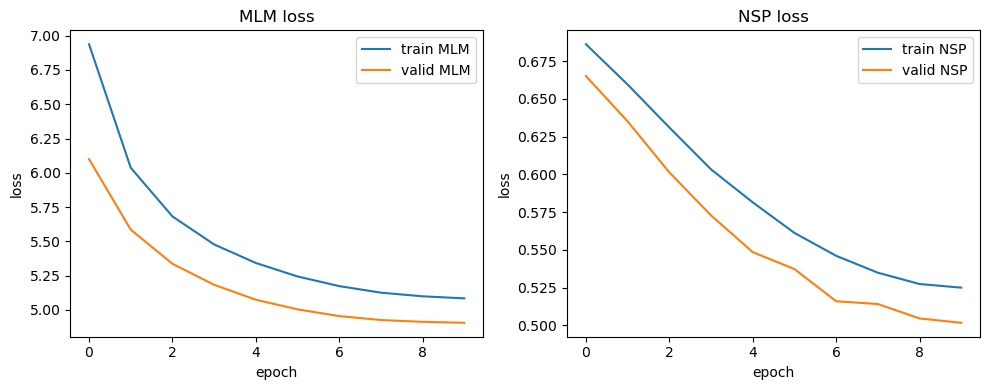

In [11]:
base_lr = 3e-4
optimizer = optim.AdamW(model.parameters(), lr=base_lr)

num_epochs = 10
num_train_steps = num_epochs * len(train_loader)

# 간단한 cosine 스케줄 (warmup 없이)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_train_steps, eta_min=1e-5
)

# history: loss + accuracy 모두 기록
train_history = {"mlm_loss": [], "nsp_loss": [], "mlm_acc": [], "nsp_acc": []}
valid_history = {"mlm_loss": [], "nsp_loss": [], "mlm_acc": [], "nsp_acc": []}

ckpt_dir = os.getenv("HOME") + "/work/bert_pretrain/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

start_epoch = 1
ckpt_path = os.path.join(ckpt_dir, "mini_bert_last.pt")

# vocab_size가 바뀐 경우 이전 ckpt는 사용하지 않도록 주석 처리 or 조건 추가
use_checkpoint = True

# 체크포인트에서 재시작 (있으면)
if use_checkpoint and os.path.exists(ckpt_path):
    print(f"Loading checkpoint from {ckpt_path}")
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    train_history = state["train_history"]
    valid_history = state["valid_history"]
    start_epoch = state["epoch"] + 1
    print(f"Resume training from epoch {start_epoch}")

global_step = (start_epoch - 1) * len(train_loader)

for epoch in range(start_epoch, num_epochs + 1):
    model.train()
    total_mlm, total_nsp = 0.0, 0.0
    total_mlm_acc, total_nsp_acc = 0.0, 0.0
    steps = 0

    for batch in tqdm(train_loader, desc=f"epoch {epoch} train"):
        input_ids, seg_ids, attn_mask, mlm_labels, nsp_labels = [
            x.to(device) for x in batch
        ]

        optimizer.zero_grad()
        loss, mlm_loss, nsp_loss, mlm_logits, nsp_logits = model(
            input_ids, seg_ids, attn_mask,
            mlm_labels=mlm_labels,
            nsp_labels=nsp_labels
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        global_step += 1

        total_mlm += mlm_loss.item()
        total_nsp += nsp_loss.item()
        total_mlm_acc += mlm_accuracy(mlm_logits, mlm_labels)
        total_nsp_acc += nsp_accuracy(nsp_logits, nsp_labels)
        steps += 1

    avg_mlm = total_mlm / steps
    avg_nsp = total_nsp / steps
    avg_mlm_acc = total_mlm_acc / steps
    avg_nsp_acc = total_nsp_acc / steps

    train_history["mlm_loss"].append(avg_mlm)
    train_history["nsp_loss"].append(avg_nsp)
    train_history["mlm_acc"].append(avg_mlm_acc)
    train_history["nsp_acc"].append(avg_nsp_acc)

    # validation
    model.eval()
    v_mlm, v_nsp = 0.0, 0.0
    v_mlm_acc, v_nsp_acc = 0.0, 0.0
    v_steps = 0

    with torch.no_grad():
        for batch in valid_loader:
            input_ids, seg_ids, attn_mask, mlm_labels, nsp_labels = [
                x.to(device) for x in batch
            ]
            _, mlm_loss, nsp_loss, mlm_logits, nsp_logits = model(
                input_ids, seg_ids, attn_mask,
                mlm_labels=mlm_labels,
                nsp_labels=nsp_labels
            )
            v_mlm += mlm_loss.item()
            v_nsp += nsp_loss.item()
            v_mlm_acc += mlm_accuracy(mlm_logits, mlm_labels)
            v_nsp_acc += nsp_accuracy(nsp_logits, nsp_labels)
            v_steps += 1

    v_mlm /= v_steps
    v_nsp /= v_steps
    v_mlm_acc /= v_steps
    v_nsp_acc /= v_steps

    valid_history["mlm_loss"].append(v_mlm)
    valid_history["nsp_loss"].append(v_nsp)
    valid_history["mlm_acc"].append(v_mlm_acc)
    valid_history["nsp_acc"].append(v_nsp_acc)

    print(
        f"[Epoch {epoch}] "
        f"train MLM: {avg_mlm:.4f}, NSP: {avg_nsp:.4f}, "
        f"MLM acc: {avg_mlm_acc:.4f}, NSP acc: {avg_nsp_acc:.4f} | "
        f"valid MLM: {v_mlm:.4f}, NSP: {v_nsp:.4f}, "
        f"MLM acc: {v_mlm_acc:.4f}, NSP acc: {v_nsp_acc:.4f}"
    )

    # 체크포인트 저장 (마지막 + best)
    last_ckpt = {
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "train_history": train_history,
        "valid_history": valid_history,
    }
    torch.save(last_ckpt, ckpt_path)

    best_ckpt_path = os.path.join(ckpt_dir, "mini_bert_best.pt")
    if epoch == 1 or v_mlm <= min(valid_history["mlm_loss"]):
        torch.save(last_ckpt, best_ckpt_path)

# 학습 곡선 시각화 (loss만, acc는 원하면 추가 plot)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_history["mlm_loss"], label="train MLM")
plt.plot(valid_history["mlm_loss"], label="valid MLM")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("MLM loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_history["nsp_loss"], label="train NSP")
plt.plot(valid_history["nsp_loss"], label="valid NSP")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("NSP loss")
plt.legend()

plt.tight_layout()
plt.show()

### 7. 예시로 MLM/NSP qualititative 확인

In [12]:
def show_mlm_prediction(text_a, text_b, mask_prob=0.20):
    model.eval()
    ids, seg_ids, attn_mask = build_input_ids(text_a, text_b, max_seq_len)
    mlm_input_ids, mlm_labels = create_mlm_labels(ids, mlm_prob=mask_prob)

    input_ids_t = torch.tensor([mlm_input_ids], device=device)
    seg_ids_t = torch.tensor([seg_ids], device=device)
    attn_mask_t = torch.tensor([attn_mask], device=device)
    mlm_labels_t = torch.tensor([mlm_labels], device=device)
    with torch.no_grad():
        _, _, _, mlm_logits, nsp_logits = model(
            input_ids_t, seg_ids_t, attn_mask_t,
            mlm_labels=mlm_labels_t,
            nsp_labels=torch.tensor([1], device=device)
        )
    pred_ids = mlm_logits.argmax(-1).cpu().numpy()[0]
    print("input: ", vocab.DecodeIds(ids))
    print("masked:", vocab.DecodeIds(mlm_input_ids))
    print("pred:  ", vocab.DecodeIds(pred_ids.tolist()))
    print("NSP logits:", nsp_logits.cpu().numpy())

In [13]:
# 예시 호출 (원하면 주석 해제)
show_mlm_prediction("서울은 대한민국의 수도이다.", "한강은 서울을 가로질러 흐른다.")
show_mlm_prediction("물은 섭씨 100도에서 끓는다.", "섭씨 0도에서는 얼음이 된다.")
show_mlm_prediction("오늘 날씨가 정말 좋다.", "공원에는 사람들이 많이 모였다.")

input:  [CLS] 서울은 대한민국의 수도이다.[SEP] 한강은 서울을 가로질러 흐른다.[SEP]
masked: [CLS] 서울은 대한민국의[MASK]이다[MASK][SEP] 한강은 서울을 가로질러 흐른다.[SEP]
pred:   도시 대한민국은 대한민국의 정치이다.. 이칭은 명칭을 흘로 흘로 지다.. 성우 지하 노선 승강장역이다이다이다이다... 있다. 설치되어.... 있다.역이다.. 설치되어......이다 설치되어 있다 있다이다 노선 개통이다이다이다이다.. 있다 있다가. 있다이다. 노선대학. 있다. 설치되어 설치되어 있다. 있다 있다되었다. 설치되어 있다이다. 역.. 지하 승강장... 있다. 있다 있다이다 설치되어. 개통. 있다... 있다 개통이다 있다.... 있다 있다.. 있다 있다.. 있다 있다.
NSP logits: [[-0.31664288  0.9079162 ]]
input:  [CLS] 물은 섭씨 100도에서 끓는다.[SEP] 섭씨 0도에서는 얼음이 된다.[SEP]
masked: [CLS] 물은 섭씨 100도[MASK] 끓[MASK][MASK][SEP] 섭씨 0도에서는 얼음이[MASK].[SEP]
pred:   고 이것은 사위 중세, 좁다., 사안스세기에서는 기음이 있다.. 같다.다다.다가 있다다이다고다고이다.고.다다.다기도가가기도다기도다다.어이다다다.이다..의다의다라고어다이다이다.고다다다다다.. 있다 있다.을 큰다..다다다.기도다. 있다.....다다...도.이다기도다다의다기도.다라고......이다가라고.
NSP logits: [[-0.06895152  0.7075793 ]]
input:  [CLS] 오늘 날씨가 정말 좋다.[SEP] 공원에는 사람들이 많이 모였다.[SEP]
masked: [CLS] 오늘 날씨[MASK] 정말 좋다[MASK][SEP] 공[MASK]에는 사람들이 많이 모였다.[SEP]
pred:   이 또한 동산은 지장을 나다., 동학에는 가장 같은 쓰다.는 같다이다이다이다이다이다..이다 있다...이다이다.이다이다이다..이다.이다